# EDA

In [17]:
# Imports

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score , accuracy_score

sys.path.append(os.path.join(".."))
sys.path.append(os.path.join("../src"))

from preprocessing import get_X_y , get_X

In [2]:
# Data Load

df_train = pd.read_csv("../dataset/train.csv")
df_test = pd.read_csv("../dataset/test.csv")

df_train

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [3]:
# Stats

print(df_train.describe())

               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8514.000000   8512.000000   8510.000000   8485.000000   8510.000000   
mean     28.827930    224.687617    458.077203    173.729169    311.138778   
std      14.489021    666.717663   1611.489240    604.696458   1136.705535   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      19.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      38.000000     47.000000     76.000000     27.000000     59.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8505.000000  
mean     304.854791  
std     1145.717189  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       46.000000  
max    24133.000000  


In [4]:
# Null Values

print(df_train.isnull().sum())

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


# There are too many NAN vaues in this dataset , I handled it in : 
# src -> preprocessing.py

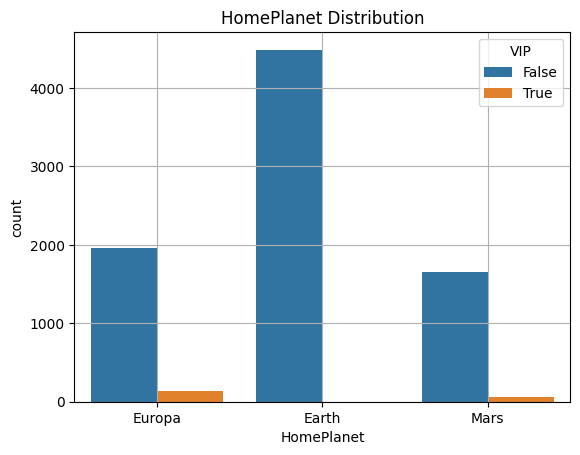

In [5]:
# HomePlanet Distribution

sns.countplot(
    x = "HomePlanet" ,
    hue = "VIP" ,
    data = df_train
)

plt.title("HomePlanet Distribution")
plt.grid()
plt.show()

# We can clearly see that all the VIP's are from either Europa or Mars .
# Earth planet contributes highest passengers

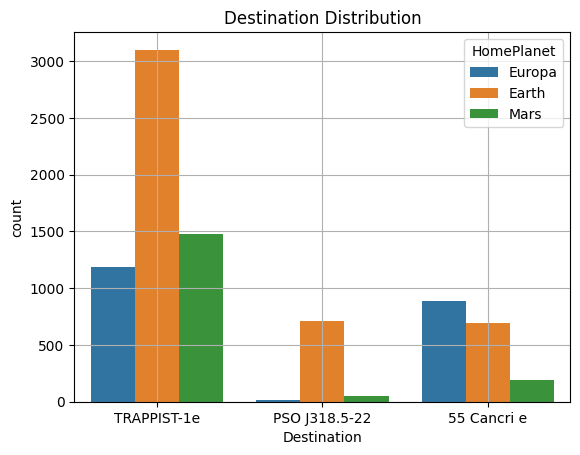

In [6]:
# Destination Distribution

sns.countplot(
    x = "Destination" ,
    hue = "HomePlanet" ,
    data = df_train
)

plt.title("Destination Distribution")
plt.grid()
plt.show()

# Most of the passengers want to go "TRAPPOST-1e" but as but EUROPA people are attracted more toward "55 Cancri e" as compared to other

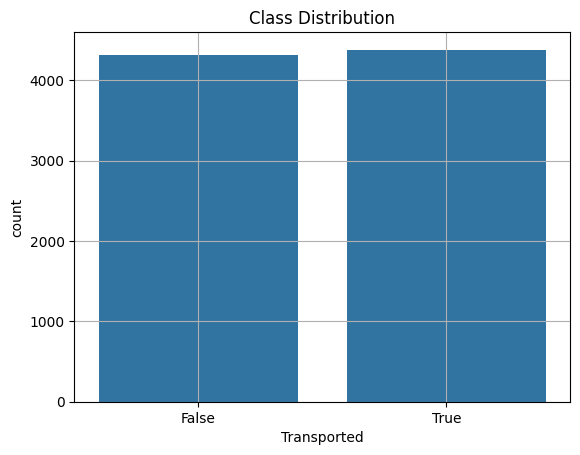

In [7]:
# Imbalance Check

sns.countplot(
    x = "Transported" ,
    data = df_train
)

plt.title("Class Distribution")
plt.grid()
plt.show()

# This dataset is accurately balanced

In [8]:
# Preprocessing

X , y = get_X_y(df_train)

X_train , X_val , y_train , y_val = train_test_split(
    X ,
    y ,
    test_size = 0.1 ,
    random_state = 9
)

In [13]:
# Base Model

cat_cols = X_train.select_dtypes(include = ["object" , "string"]).columns
num_cols = X_train.select_dtypes(include = ["number"]).columns


preprocess = ColumnTransformer([
    ("cat" , OneHotEncoder(handle_unknown= "ignore") , cat_cols)
] , remainder = "passthrough"
)

model = Pipeline([
    ("preprcoess" , preprocess) ,
    ("rf" , RandomForestClassifier())
])

model.fit(X_train , y_train)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprcoess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spars

In [14]:
# Base Model Score

y_pred = model.predict(X_val)

f1 = f1_score(y_val , y_pred)
ac = accuracy_score(y_val , y_pred)

print(f"F1 Score : {f1}")
print(f"Accuracy Score : {ac}")

F1 Score : 0.8210526315789474
Accuracy Score : 0.8218859138533178


In [15]:
# Feature Importance

rf = model.named_steps["rf"]

feature_names = model.named_steps["preprcoess"].get_feature_names_out()
imp =  rf.feature_importances_

imp = pd.Series(imp , index = feature_names).sort_values(ascending = False)

imp

remainder__Group                  0.119870
remainder__CabinNum               0.119615
remainder__Age                    0.113439
remainder__Spa                    0.091466
remainder__VRDeck                 0.080018
remainder__FoodCourt              0.072869
remainder__RoomService            0.069567
cat__CryoSleep_True               0.068744
remainder__ShoppingMall           0.061440
cat__CryoSleep_False              0.060577
cat__HomePlanet_Europa            0.016944
cat__HomePlanet_Earth             0.016389
cat__Deck_G                       0.015255
cat__Deck_F                       0.011345
cat__Deck_E                       0.011205
cat__Side_S                       0.010999
cat__Side_P                       0.010814
cat__Destination_TRAPPIST-1e      0.009681
cat__Destination_55 Cancri e      0.008555
cat__HomePlanet_Mars              0.008099
cat__Destination_PSO J318.5-22    0.005384
cat__Deck_C                       0.005287
cat__Deck_B                       0.004125
cat__Deck_D